# **Tugas2**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

Original image loaded successfully.
Image format: JPEG
Image size: (636, 660)


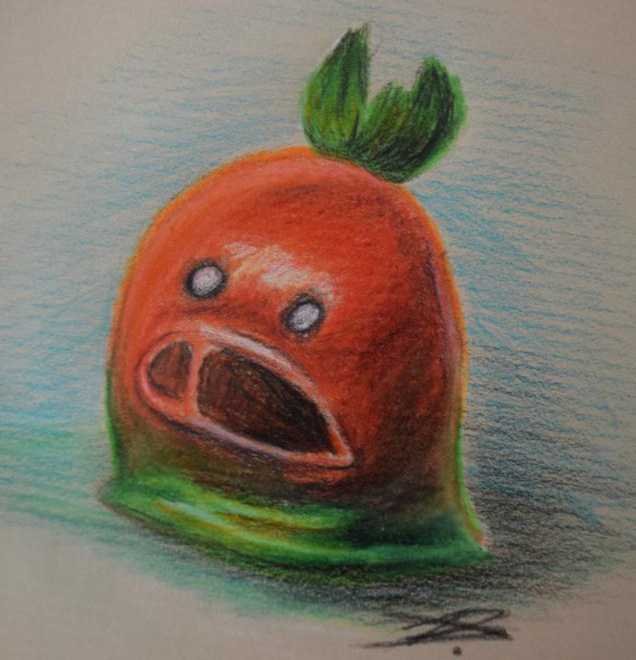

In [2]:
image_url = "https://raw.githubusercontent.com/KevinAndT25/DIF62130_A_25_2311532005_KevinAndhika/b56d834088e4d2e8fca675d2bc9373f925524706/IMG_20200910_175853_260.jpg"

response = requests.get(image_url)
img = Image.open(BytesIO(response.content))

print("Original image loaded successfully.")
print(f"Image format: {img.format}")
print(f"Image size: {img.size}")
img

Image converted to grayscale.
Array shape: (660, 636)
Data type: uint8
Min value: 12, Max value: 180


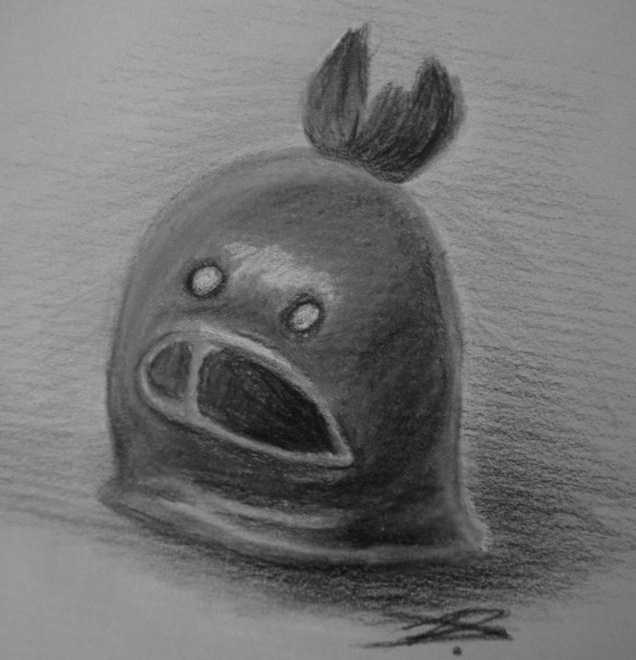

In [3]:
# Konversi ke grayscale
img_gray = img.convert('L')
img_array = np.array(img_gray)

print(f"Image converted to grayscale.")
print(f"Array shape: {img_array.shape}")
print(f"Data type: {img_array.dtype}")
print(f"Min value: {img_array.min()}, Max value: {img_array.max()}")
img_gray

In [4]:
# Fungsi untuk menghitung histogram manual
def hitung_histogram(citra_array):
    """Menghitung histogram citra grayscale dengan rentang 0-255"""
    histogram = np.zeros(256, dtype=int)
    for baris in citra_array:
     for piksel in baris:
        histogram[piksel] += 1
        return histogram



In [5]:
# Fungsi untuk normalisasi histogram
def normalisasi_histogram(histogram, total_piksel):
    """Menormalisasi histogram dengan membagi setiap nilai dengan total piksel"""
    return histogram.astype(float) / total_piksel


In [6]:
# Hitung histogram asli
hist_asli = hitung_histogram(img_array)
total_piksel = img_array.shape[0] * img_array.shape[1]
print(f"\nTotal piksel: {total_piksel}")
print("Histogram asli selesai dihitung.")

# Normalisasi histogram
hist_normalisasi = normalisasi_histogram(hist_asli, total_piksel)
print("Histogram ternormalisasi selesai dihitung.")




Total piksel: 419760
Histogram asli selesai dihitung.
Histogram ternormalisasi selesai dihitung.


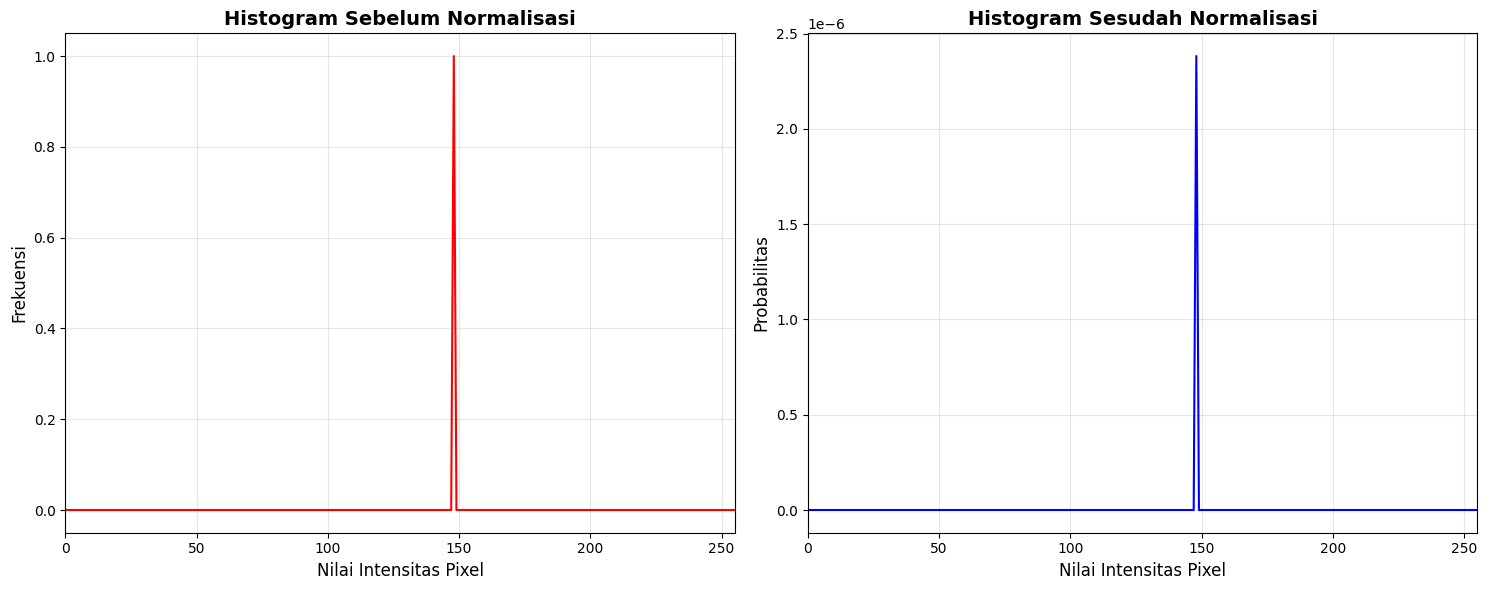

In [8]:
plt.figure(figsize=(15, 6))

# Subplot 1: Histogram Sebelum Normalisasi
plt.subplot(1, 2, 1)
plt.plot(hist_asli, color='red', linewidth=1.5)
plt.title('Histogram Sebelum Normalisasi', fontsize=14, fontweight='bold')
plt.xlabel('Nilai Intensitas Pixel', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, 255)

# Subplot 2: Histogram Sesudah Normalisasi
plt.subplot(1, 2, 2)
plt.plot(hist_normalisasi, color='blue', linewidth=1.5)
plt.title('Histogram Sesudah Normalisasi', fontsize=14, fontweight='bold')
plt.xlabel('Nilai Intensitas Pixel', fontsize=12)
plt.ylabel('Probabilitas', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, 255)

plt.tight_layout()
plt.show()

# **Tugas3**

In [9]:
# Menghitung Cumulative Distribution Function dari histogram ternormalisasi
cdf = np.zeros(256, dtype=float)
cdf[0] = hist_normalisasi[0]
for i in range(1, 256):
    cdf[i] = cdf[i-1] + hist_normalisasi[i]

In [10]:
if cdf.max() < 0.999:
      print("Menormalisasi CDF...")
      cdf = cdf / cdf.max()
      print(f"CDF setelah normalisasi: {cdf.min():.4f} - {cdf.max():.4f}")


Menormalisasi CDF...
CDF setelah normalisasi: 0.0000 - 1.0000


In [11]:
# Membuat lookup table untuk transformasi intensitas
lookup_table = np.round(cdf * 255).astype(int)

# Mengaplikasikan lookup table ke citra
img_equalized = np.zeros_like(img_array)
for i in range(img_array.shape[0]):
 for j in range(img_array.shape[1]):
  intensitas_lama = img_array[i, j]
  intensitas_baru = lookup_table[intensitas_lama]
  img_equalized[i, j] = intensitas_baru



In [12]:
# Menghitung histogram citra hasil equalization
hist_equalized = np.zeros(256, dtype=int)
for i in range(img_array.shape[0]):
    for j in range(img_array.shape[1]):
            hist_equalized[img_equalized[i, j]] += 1

In [13]:
# Menormalisasi histogram hasil equalization
hist_equalized_norm = hist_equalized.astype(float) / total_piksel

print("Histogram equalization selesai")
print(f"Rentang intensitas baru: {img_equalized.min()} - {img_equalized.max()}")

Histogram equalization selesai
Rentang intensitas baru: 0 - 255


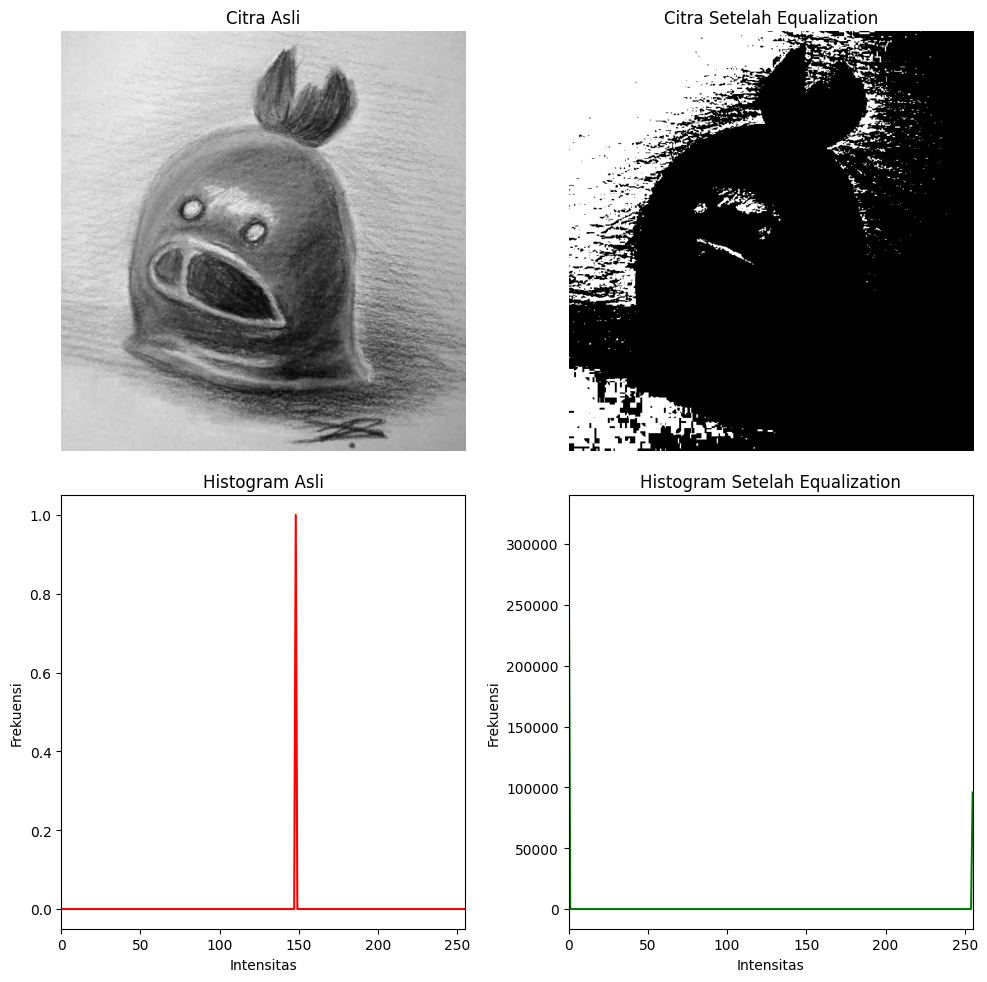

In [14]:
plt.figure(figsize=(15, 10))

# Baris 1: Citra
plt.subplot(2, 3, 1)
plt.imshow(img_array, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(img_equalized, cmap='gray')
plt.title('Citra Setelah Equalization')
plt.axis('off')

# Baris 2: Histogram
plt.subplot(2, 3, 4)
plt.plot(hist_asli, color='red')
plt.title('Histogram Asli')
plt.xlabel('Intensitas')
plt.ylabel('Frekuensi')
plt.xlim(0, 255)

plt.subplot(2, 3, 5)
plt.plot(hist_equalized, color='green')
plt.title('Histogram Setelah Equalization')
plt.xlabel('Intensitas')
plt.ylabel('Frekuensi')
plt.xlim(0, 255)

plt.tight_layout()
plt.show()
